In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Pour importer depuis ton dossier src/
import sys
sys.path.append('../src')
from model import get_model
from dataset import get_dataloaders

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Évaluation sur : {device}")

# Tes chemins d'accès (selon tes modifications)
TRAIN_PATH = "../data/raw/HAM10000_metadata"
TEST_PATH = "../data/processed/ISIC2018_Task3_Test_GroundTruth.csv"
IMG_DIR = "../data/images"
MODELS_DIR = "../models"

MODELS_TO_COMPARE = ['resnet50', 'efficientnet_b0', 'densenet121']

Évaluation sur : cpu


In [2]:
# On charge les données (On met sample_size=None pour évaluer sur TOUT le set de test)
_, test_loader, class_to_idx, _ = get_dataloaders(
    TRAIN_PATH, TEST_PATH, IMG_DIR, batch_size=32, sample_size=None
)

idx_to_class = {v: k for k, v in class_to_idx.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
NUM_CLASSES = len(target_names)

print(f"Classes détectées : {target_names}")

Classes détectées : ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']


In [3]:
def evaluate_model(model_name):
    print(f"Évaluation de {model_name}...")
    
    # 1. Charger l'architecture
    model = get_model(model_name, num_classes=NUM_CLASSES).to(device)
    
    # 2. Charger les poids entraînés
    weights_path = os.path.join(MODELS_DIR, f"best_{model_name}.pth")
    if not os.path.exists(weights_path):
        print(f"⚠️ Fichier {weights_path} introuvable. As-tu entraîné ce modèle ?")
        return None, None, None
        
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = [] # On stocke les probabilités pour les courbes ROC
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Probabilités (Softmax)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Dictionnaire pour stocker les résultats de tous les modèles
results = {}

for m in MODELS_TO_COMPARE:
    y_true, y_pred, y_probs = evaluate_model(m)
    if y_true is not None:
        results[m] = {'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

Évaluation de resnet50...
Évaluation de efficientnet_b0...
Évaluation de densenet121...


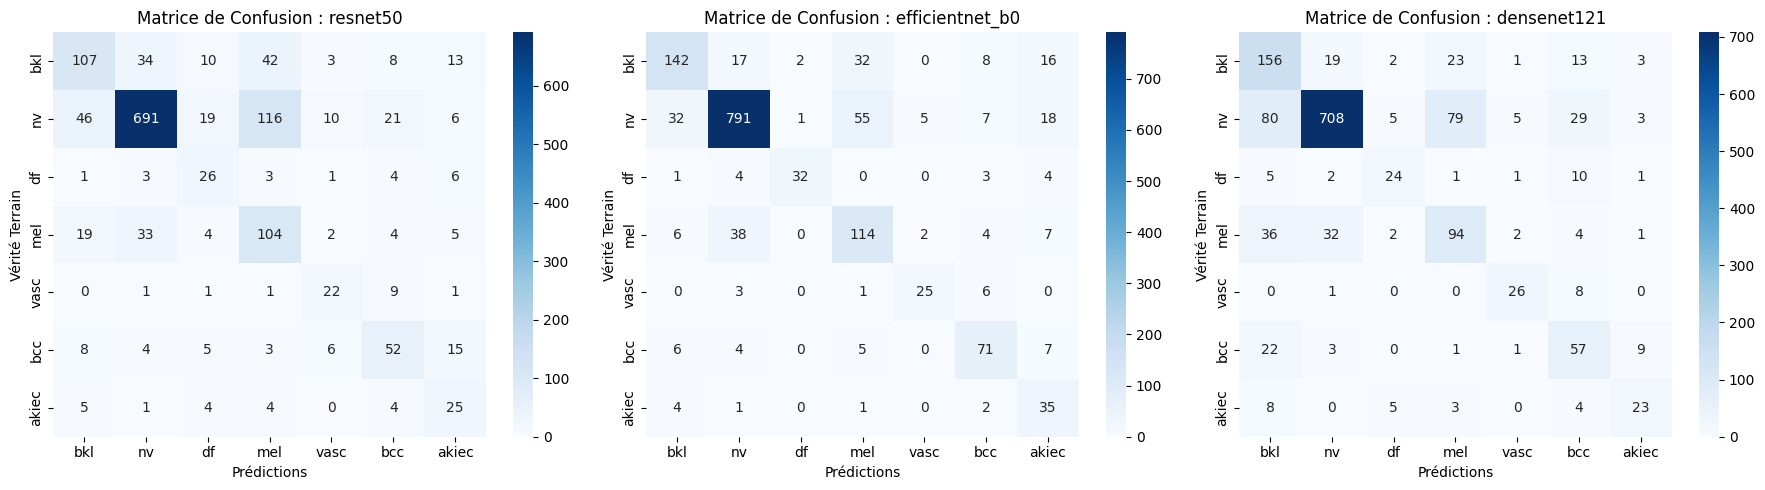

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))

for idx, (model_name, data) in enumerate(results.items()):
    cm = confusion_matrix(data['y_true'], data['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=target_names, yticklabels=target_names)
    
    axes[idx].set_title(f'Matrice de Confusion : {model_name}')
    axes[idx].set_xlabel('Prédictions')
    axes[idx].set_ylabel('Vérité Terrain')

plt.tight_layout()
plt.show()


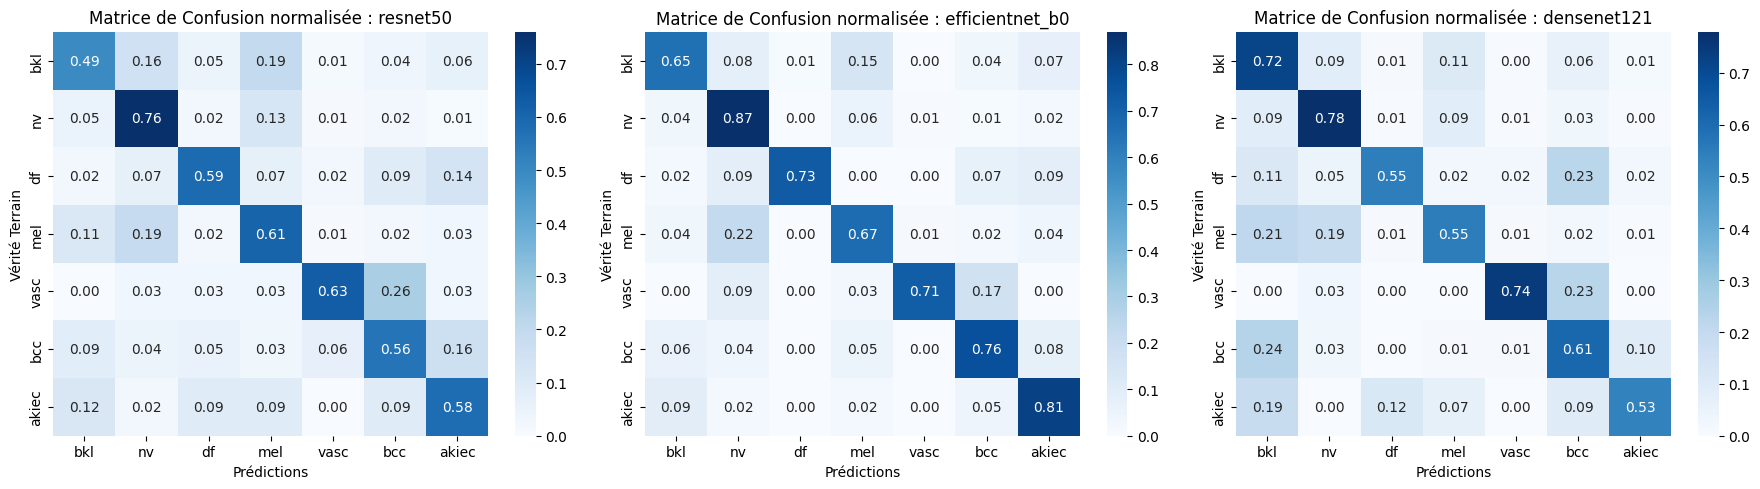

In [8]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))

for idx, (model_name, data) in enumerate(results.items()):
    cm = confusion_matrix(data['y_true'], data['y_pred'])

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx],
                xticklabels=target_names, yticklabels=target_names)
    
    axes[idx].set_title(f'Matrice de Confusion normalisée : {model_name}')
    axes[idx].set_xlabel('Prédictions')
    axes[idx].set_ylabel('Vérité Terrain')

plt.tight_layout()
plt.show()




In [5]:
for model_name, data in results.items():
    print(f"\n{'='*50}")
    print(f"📊 RAPPORT POUR : {model_name.upper()}")
    print(f"{'='*50}")
    print(classification_report(data['y_true'], data['y_pred'], target_names=target_names, zero_division=0))


📊 RAPPORT POUR : RESNET50
              precision    recall  f1-score   support

         bkl       0.58      0.49      0.53       217
          nv       0.90      0.76      0.82       909
          df       0.38      0.59      0.46        44
         mel       0.38      0.61      0.47       171
        vasc       0.50      0.63      0.56        35
         bcc       0.51      0.56      0.53        93
       akiec       0.35      0.58      0.44        43

    accuracy                           0.68      1512
   macro avg       0.51      0.60      0.54      1512
weighted avg       0.73      0.68      0.70      1512


📊 RAPPORT POUR : EFFICIENTNET_B0
              precision    recall  f1-score   support

         bkl       0.74      0.65      0.70       217
          nv       0.92      0.87      0.90       909
          df       0.91      0.73      0.81        44
         mel       0.55      0.67      0.60       171
        vasc       0.78      0.71      0.75        35
         bcc     

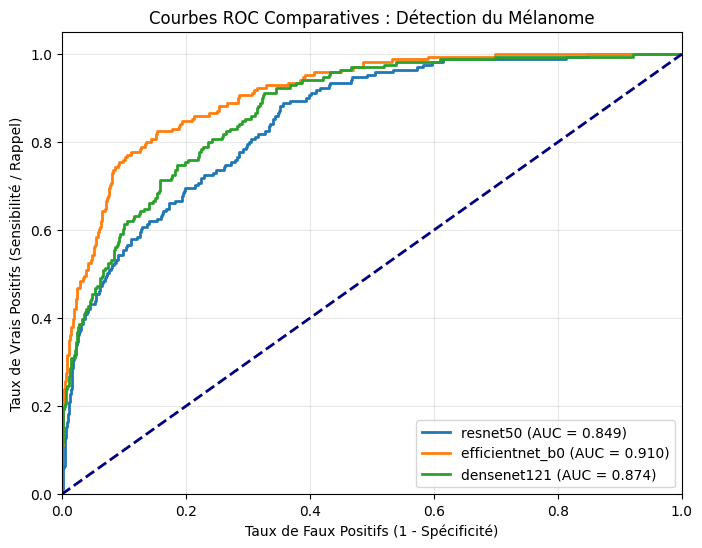

In [6]:
# Trouver l'index de la classe 'mel' (mélanome)
mel_idx = target_names.index('mel') if 'mel' in target_names else -1

if mel_idx != -1:
    plt.figure(figsize=(8, 6))
    
    for model_name, data in results.items():
        # Vrai si c'est un mélanome, Faux sinon
        y_true_binary = (data['y_true'] == mel_idx).astype(int)
        # Probabilité prédite pour la classe mélanome
        y_scores = data['y_probs'][:, mel_idx]
        
        fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
    plt.ylabel('Taux de Vrais Positifs (Sensibilité / Rappel)')
    plt.title('Courbes ROC Comparatives : Détection du Mélanome')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Classe 'mel' introuvable pour générer la courbe ROC.")